<a href="https://colab.research.google.com/github/pooyapaydary/mini-projects/blob/main/mini_project_16Nov25.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Deliverable 1 — Distributions & Basic Plots

Using Matplotlib and Seaborn, create:

1. Histogram of DO (overall)

Add mean & median vertical lines.

Customize colors and grid.

2. Boxplot of DO by Season

Show seasonal differences clearly.

Add your own style (palette, linewidth, etc.)

3. Violin plot of pH by Station

Practice violin shapes, bandwidth, inner="box".

4. Scatterplot: pH vs DO

Add regression line using seaborn’s regplot.

Label each axis properly.

In [212]:
import numpy as np
import pandas as pd

np.random.seed(42)

stations = ['ST01', 'ST02', 'ST03', 'ST04']
seasons = ['Winter', 'Spring', 'Summer', 'Fall']

rows = []
for st in stations:
    for s in seasons:
        # DO means vary by season
        base_do = {
            'Winter': 10.5,
            'Spring': 9.0,
            'Summer': 7.5,
            'Fall': 8.5
        }[s]

        # pH slight variation
        base_ph = {
            'Winter': 7.4,
            'Spring': 7.2,
            'Summer': 7.0,
            'Fall': 7.3
        }[s]

        # generate 40 observations per station-season
        for i in range(40):
            rows.append({
                'station': st,
                'season': s,
                'DO': np.random.normal(base_do, 0.7),
                'pH': np.random.normal(base_ph, 0.15)
            })

df = pd.DataFrame(rows)
df.head()


,station,season,DO,pH
0,ST01,Winter,10.847700,7.379260
1,ST01,Winter,10.953382,7.628454
2,ST01,Winter,10.336093,7.364879
3,ST01,Winter,11.605449,7.515115
4,ST01,Winter,10.171368,7.481384


In [213]:
#lets first look at the data
print(df.info())
print("\n")
print(df["season"].unique())
print("\n")
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 640 entries, 0 to 639
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   station  640 non-null    object 
 1   season   640 non-null    object 
 2   DO       640 non-null    float64
 3   pH       640 non-null    float64
dtypes: float64(2), object(2)
memory usage: 20.1+ KB
None


['Winter' 'Spring' 'Summer' 'Fall']


               DO          pH
count  640.000000  640.000000
mean     8.905442    7.230375
std      1.261706    0.213038
min      5.750416    6.676991
25%      7.943768    7.086417
50%      8.835996    7.238945
75%      9.818842    7.369667
max     12.301352    7.721341


In [214]:
#importing libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


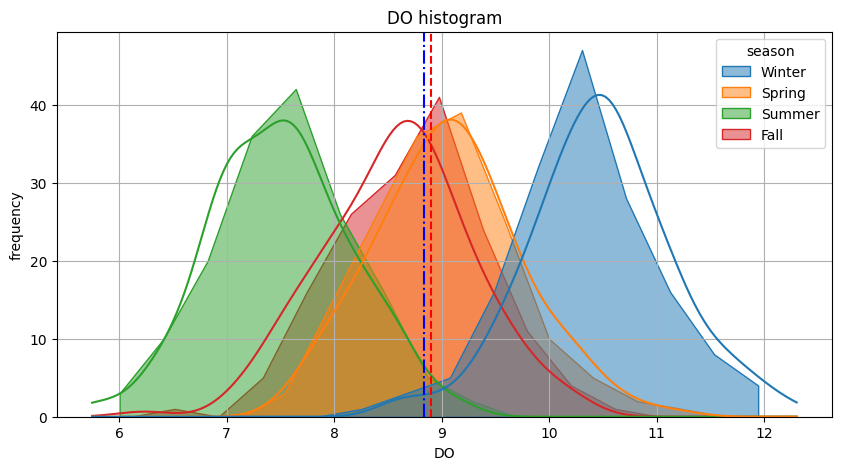

In [215]:
#1. Histogram of DO (overall)
fig=plt.figure(figsize=(10,5))
avg=df["DO"].mean()
med=df["DO"].median()
sns.histplot(df, x="DO", color="r", hue="season", stat="count", multiple="dodge", kde=True, element="poly",common_norm=False)
plt.axvline(avg, color="r", linestyle="--", label="mean")
plt.axvline(med, color="b", linestyle="-.", label="median")
plt.title("DO histogram")
plt.xticks()
plt.grid(True)
plt.xlabel("DO")
plt.ylabel("frequency")
plt.show()

Text(0, 0.5, 'DO')

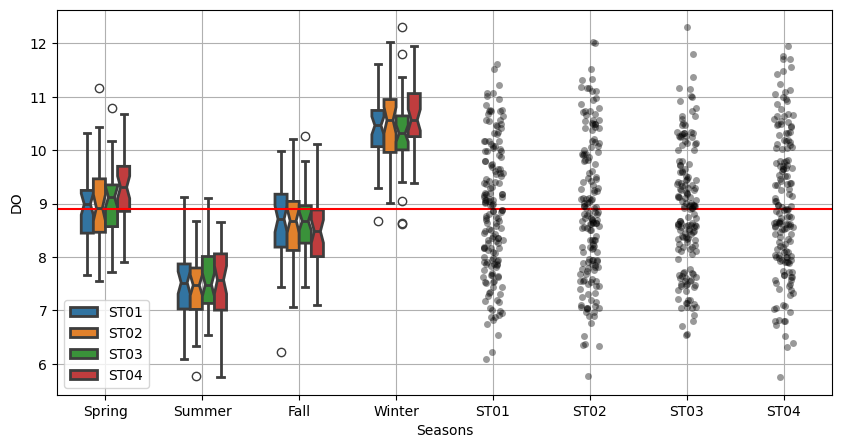

In [216]:
#Boxplot of DO by Season
#Show seasonal differences clearly.
fig=plt.figure(figsize=(10,5),facecolor="white")
sns.boxplot(df, y="DO", x="season", order=["Spring", "Summer", "Fall", "Winter"], width=.5, hue="station", linewidth=2, notch=True)
sns.stripplot(x='station', y='DO', data=df, color='black', alpha=0.4)
plt.axhline(avg, color="r")
plt.style.use('default')
plt.grid(True)
plt.xlabel("Seasons")
plt.ylabel("DO")



In [217]:
#Violin plot of pH by Station
#Practice violin shapes, bandwidth, inner="box".

/tmp/ipython-input-2346089847.py:2: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='count'` for the same effect.
  sns.violinplot(df, y="DO", x="station",hue="season",split=True, palette="Set2", inner="quartile", cut=4, bw=1, scale="count", scale_hue=False)
/tmp/ipython-input-2346089847.py:2: FutureWarning: 

The `scale_hue` parameter has been replaced and will be removed in v0.15.0. Pass `common_norm=True` for the same effect.
  sns.violinplot(df, y="DO", x="station",hue="season",split=True, palette="Set2", inner="quartile", cut=4, bw=1, scale="count", scale_hue=False)
/tmp/ipython-input-2346089847.py:2: FutureWarning: 

The `bw` parameter is deprecated in favor of `bw_method`/`bw_adjust`.
Setting `bw_method=1`, but please see docs for the new parameters
and update your code. This will become an error in seaborn v0.15.0.

  sns.violinplot(df, y="DO", x="station",hue="season",split=True, palette="Set2", inner="quartile", cut=4

Text(0, 0.5, 'DO')

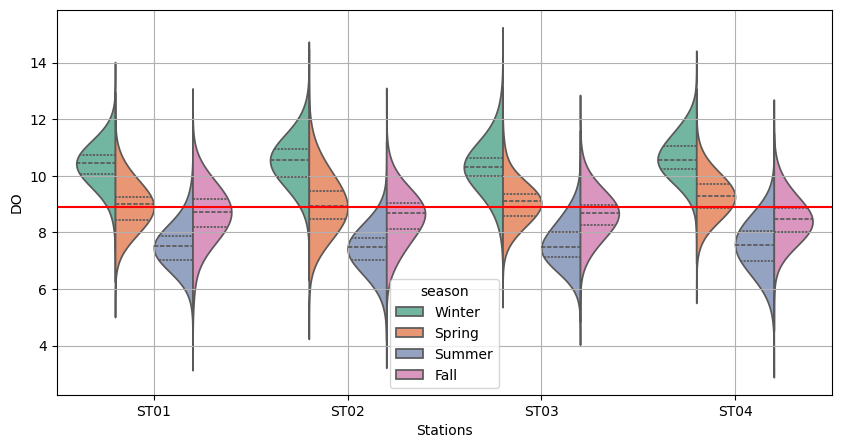

In [218]:
fig=plt.figure(figsize=(10,5),facecolor="white")
sns.violinplot(df, y="DO", x="station",hue="season",split=True, palette="Set2", inner="quartile", cut=4, bw=1, scale="count", scale_hue=False)
plt.axhline(avg, color="r")
plt.style.use('default')
plt.grid(True)
plt.xlabel("Stations")
plt.ylabel("DO")


Text(0.5, 1.0, 'pH vs DO')

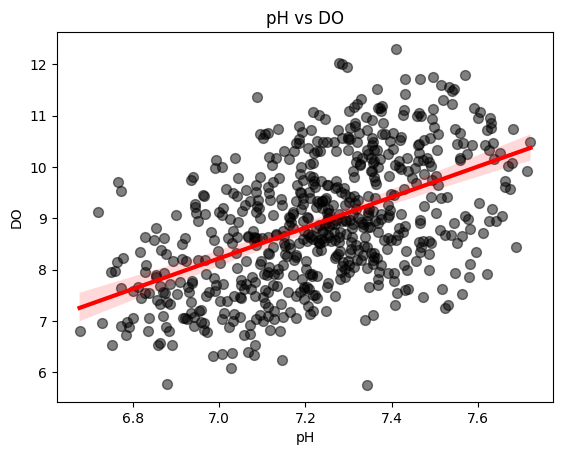

In [219]:
#Scatterplot: pH vs DO
#Add regression line using seaborn’s regplot.

#Label each axis properly.

sns.regplot(x='pH', y='DO', data=df, scatter=True, fit_reg=True, ci=99, line_kws={'color':'red', 'linewidth':3}, scatter_kws={'color':"black" ,'alpha':0.5, 's':50})
plt.title("pH vs DO")

#Deliverable 2 — Time-Independent “Seasonal Trend” Visualization

#Since we don’t have dates, simulate a seasonal trend using category ordering.

#Create:

Line plot of mean DO per season

Sort seasons Winter → Spring → Summer → Fall

Show error bars (std dev)

Bar plot of mean pH per station

Add numerical labels on bars

Add custom x-axis formatting

<class 'numpy.ndarray'>


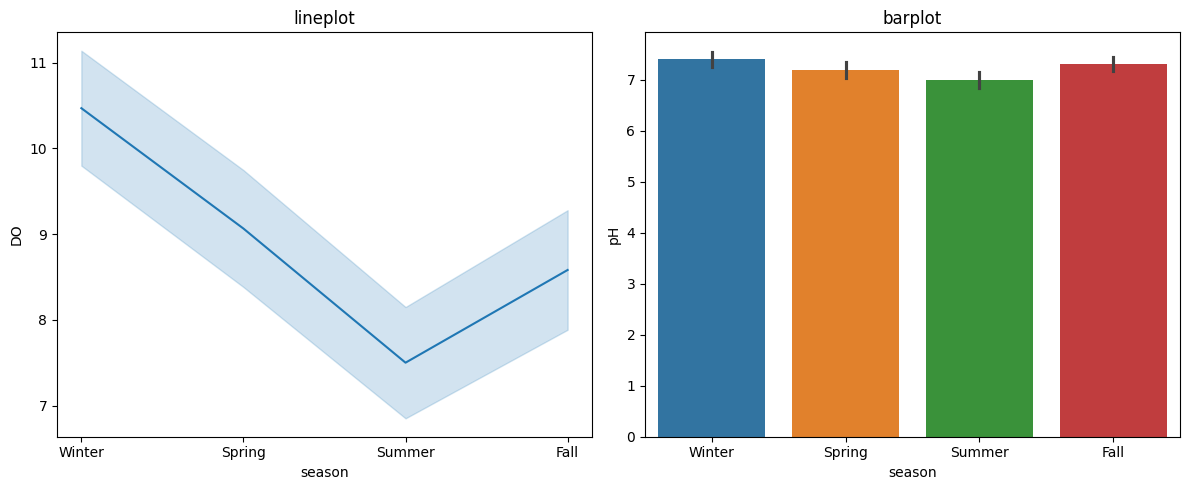

In [225]:

fig, axes=plt.subplots(1,2, figsize=(12,5))
axes[0].set_title("lineplot")
sns.lineplot(df, x="season", y="DO", errorbar=("sd",1),ax=axes[0])
axes[1].set_title("barplot")
sns.barplot(df, x="season", y="pH", errorbar=("sd",1),ax=axes[1], hue="season")
plt.tight_layout()
print(type(axes))

Compute and present:

Mean, Median, Std Dev

IQR

Count

Correlation (DO vs pH)

In [236]:
for i in ["DO", "pH"]:
  print(f"mean : {df[i].mean()} ")
  print(f"median : {df[i].median()} ")
  print(f"std : {df[i].std()} ")
  print(f"IQR: {df[i].quantile(.75)-df[i].quantile(.25)}")
  print(f"count : {df[i].count()} ")

  print("\n")
df["DO"].corr(df["pH"])

mean : 8.905442422620945 
median : 8.835996170119088 
std : 1.2617057672098488 
IQR: 1.8750738591636953
count : 640 


mean : 7.230374726169316 
median : 7.238944879460177 
std : 0.2130383461378628 
IQR: 0.2832498340647227
count : 640 




np.float64(0.5044980591381311)

Perform:

Shapiro-Wilk test for normality for DO (overall)

Q-Q plot for DO

Interpretation (is DO approx. normal?)

Empirical probability:

“Probability DO > 9 mg/L”

Deliverable 5 — Hypothesis Testing

Choose one or more tests:

A. One-way ANOVA:

Is DO significantly different between seasons?

B. Two-sample t-test:

Pick any two stations and test:

“Is mean pH different between ST01 and ST02?”

C. Tukey Post-Hoc (optional)

If ANOVA is significant, follow with Tukey.

Deliverable 6 — Mini-Report (Markdown / PDF)

A clean, short report (like for a QC water review):

Objective

Plots

Statistical findings

Interpretation

Conclusions

Future work